In [1]:
# Load packages
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(patchwork)
library(tidyverse)
# library(reshape2)
library(stringr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following object is masked from ‘package:hms’:

    hms


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.1     ✔ stringr 1.5.2
✔ readr   2.1.5     ✔ tibble  3.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ lubridate::hms() masks hms::hms()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
getwd()

[1] "/home/strawperry/Downloads"

In [3]:
# Load tsv from plate reader - synergy 
od600 <- read_tsv("od600_synergy.tsv")
head(od600)

Rows: 49 Columns: 97
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl  (96): A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11, A12, B1, B2, B3, B4...
time  (1): Time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Time,A1,A2,A3,A4,A5,A6,A7,A8,A9,⋯,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
<time>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:59:35,0.080,0.081,0.081,0.083,0.087,0.089,0.087,0.084,0.087,⋯,0.098,0.126,0.082,0.103,0.108,0.104,0.086,0.087,0.089,0.086
01:59:35,0.080,0.081,0.080,0.082,0.087,0.088,0.087,0.085,0.087,⋯,0.110,0.165,0.082,0.117,0.123,0.121,0.086,0.087,0.089,0.086
02:59:35,0.081,0.080,0.080,0.083,0.087,0.088,0.088,0.085,0.086,⋯,0.151,0.213,0.082,0.158,0.175,0.164,0.086,0.087,0.089,0.086
03:59:35,0.081,0.081,0.080,0.083,0.087,0.093,0.084,0.084,0.087,⋯,0.200,0.273,0.081,0.201,0.245,0.209,0.086,0.087,0.089,0.086
04:59:35,0.080,0.081,0.080,0.082,0.087,0.090,0.086,0.084,0.087,⋯,0.243,0.350,0.081,0.241,0.364,0.263,0.089,0.086,0.088,0.086
05:59:35,0.080,0.081,0.080,0.082,0.087,0.086,0.092,0.086,0.086,⋯,0.289,0.440,0.082,0.290,0.500,0.332,0.088,0.086,0.088,0.086


In [22]:
# Convert time to hours
od600 <- od600 %>%
  mutate(Time_hr = round(as.numeric(Time) / 3600))

head(od600)

Time,A1,A2,A3,A4,A5,A6,A7,A8,A9,⋯,H4,H5,H6,H7,H8,H9,H10,H11,H12,Time_hr
<time>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
00:59:35,0.080,0.081,0.081,0.083,0.087,0.089,0.087,0.084,0.087,⋯,0.126,0.082,0.103,0.108,0.104,0.086,0.087,0.089,0.086,1
01:59:35,0.080,0.081,0.080,0.082,0.087,0.088,0.087,0.085,0.087,⋯,0.165,0.082,0.117,0.123,0.121,0.086,0.087,0.089,0.086,2
02:59:35,0.081,0.080,0.080,0.083,0.087,0.088,0.088,0.085,0.086,⋯,0.213,0.082,0.158,0.175,0.164,0.086,0.087,0.089,0.086,3
03:59:35,0.081,0.081,0.080,0.083,0.087,0.093,0.084,0.084,0.087,⋯,0.273,0.081,0.201,0.245,0.209,0.086,0.087,0.089,0.086,4
04:59:35,0.080,0.081,0.080,0.082,0.087,0.090,0.086,0.084,0.087,⋯,0.350,0.081,0.241,0.364,0.263,0.089,0.086,0.088,0.086,5
05:59:35,0.080,0.081,0.080,0.082,0.087,0.086,0.092,0.086,0.086,⋯,0.440,0.082,0.290,0.500,0.332,0.088,0.086,0.088,0.086,6


In [23]:
# Pivot to long format
long_od <- od600 %>%
  select(Time_hr, matches("^[A-H](?:[1-9]|1[0-2])$")) %>%
  pivot_longer(
    -Time_hr,
    names_to = "Well",
    values_to = "OD600"
  )

head(long_od)

tail(long_od)

Time_hr,Well,OD600
<dbl>,<chr>,<dbl>
1,A1,0.080
1,A2,0.081
1,A3,0.081
1,A4,0.083
1,A5,0.087
1,A6,0.089


Time_hr,Well,OD600
<dbl>,<chr>,<dbl>
49,H7,1.134
49,H8,0.960
49,H9,0.088
49,H10,0.085
49,H11,0.089
49,H12,0.088


In [24]:
# Annote conditions
library(tibble)

plate_map <- tribble(
  ~Well, ~Strain,        ~Carbon, ~Replicate,

  # Negative controls
  "A1", "None",          "M9",      1,
  "A2", "None",          "Glucose", 1,
  "A3", "None",          "Sialic",  1,
  "A4", "None",          "GMP",     1,

  # ATCC 29213
  "B1","29213","M9",1,
  "B2","29213","Glucose",1,
  "B3","29213","Sialic",1,
  "B4","29213","GMP",1,

  "C1","29213","M9",2,
  "C2","29213","Glucose",2,
  "C3","29213","Sialic",2,
  "C4","29213","GMP",2,

  "D1","29213","M9",3,
  "D2","29213","Glucose",3,
  "D3","29213","Sialic",3,
  "D4","29213","GMP",3,

  # Strain 43
  "B6","43","M9",1,
  "B7","43","Glucose",1,
  "B8","43","Sialic",1,
  "B9","43","GMP",1,

  "C6","43","M9",2,
  "C7","43","Glucose",2,
  "C8","43","Sialic",2,
  "C9","43","GMP",2,

  "D6","43","M9",3,
  "D7","43","Glucose",3,
  "D8","43","Sialic",3,
  "D9","43","GMP",3,

  # Strain 11
  "F2","11","M9",1,
  "F3","11","Glucose",1,
  "F4","11","Sialic",1,

  "G2","11","M9",2,
  "G3","11","Glucose",2,
  "G4","11","Sialic",2,

  "H2","11","M9",3,
  "H3","11","Glucose",3,
  "H4","11","Sialic",3,

  # Strain 13
  "F6","13","M9",1,
  "F7","13","Glucose",1,
  "F8","13","Sialic",1,

  "G6","13","M9",2,
  "G7","13","Glucose",2,
  "G8","13","Sialic",2,

  "H6","13","M9",3,
  "H7","13","Glucose",3,
  "H8","13","Sialic",3
)

long_od <- long_od %>%
  left_join(plate_map, by = "Well")

head(long_od)

Time_hr,Well,OD600,Strain,Carbon,Replicate
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
1,A1,0.080,None,M9,1
1,A2,0.081,None,Glucose,1
1,A3,0.081,None,Sialic,1
1,A4,0.083,None,GMP,1
1,A5,0.087,NA,NA,NA
1,A6,0.089,NA,NA,NA


In [26]:
# Remove unused wells
long_od <- long_od %>%
  filter(!is.na(Strain))

head(long_od)
tail(long_od)

Time_hr,Well,OD600,Strain,Carbon,Replicate
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
1,A1,0.080,None,M9,1
1,A2,0.081,None,Glucose,1
1,A3,0.081,None,Sialic,1
1,A4,0.083,None,GMP,1
1,B1,0.094,29213,M9,1
1,B2,0.104,29213,Glucose,1


Time_hr,Well,OD600,Strain,Carbon,Replicate
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
49,H2,0.488,11,M9,3
49,H3,0.661,11,Glucose,3
49,H4,0.966,11,Sialic,3
49,H6,0.827,13,M9,3
49,H7,1.134,13,Glucose,3
49,H8,0.960,13,Sialic,3


`geom_smooth()` using formula = 'y ~ x'


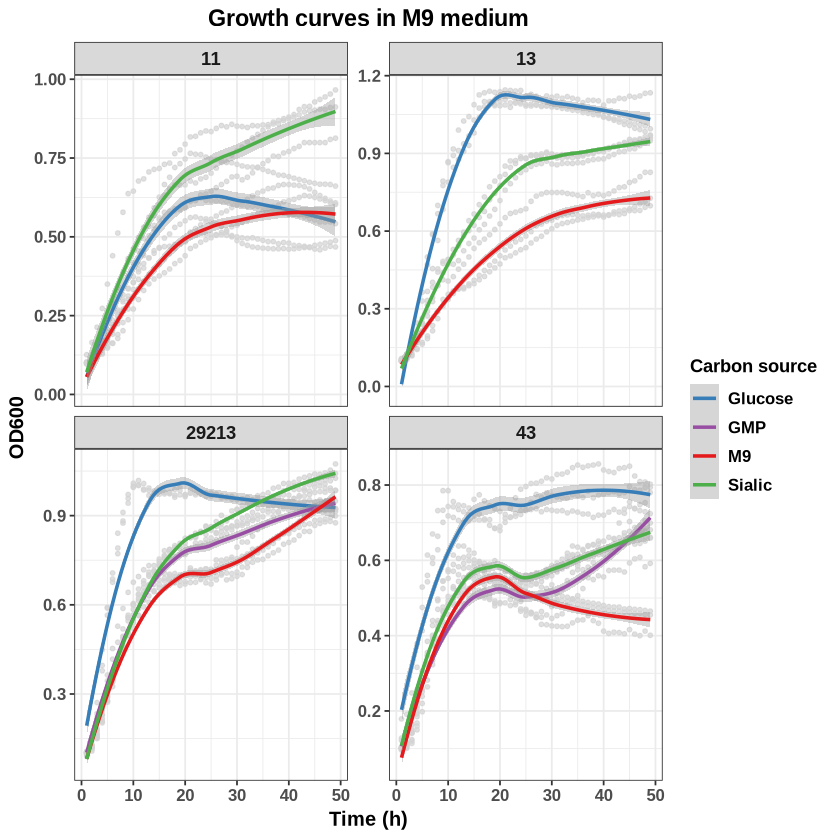

In [28]:
plotA <- ggplot(
  long_od %>%
    filter(Strain != "None"),   # remove negative controls
  aes(x = Time_hr, y = OD600)
) +
  # Raw measurements in light gray
  geom_point(
    aes(group = Well),
    color = "lightgray",
    size = 1,
    alpha = 0.7
  ) +

  # Loess trend colored by carbon source
  geom_smooth(
    aes(color = Carbon, group = Carbon),
    method = "loess",
    span = 0.8,
    se = TRUE,
    linewidth = 1
  ) +

  facet_wrap(~Strain, scales = "free_y") +

  scale_color_manual(
  values = c(
    "M9"       = "#E41A1C",
    "Glucose"  = "#377EB8",
    "Sialic"   = "#4DAF4A",
    "GMP"      = "#984EA3"
  )
) +

  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon source",
    title = "Growth curves in M9 medium"
  ) +

  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5)
  )

plotA

`geom_smooth()` using formula = 'y ~ x'


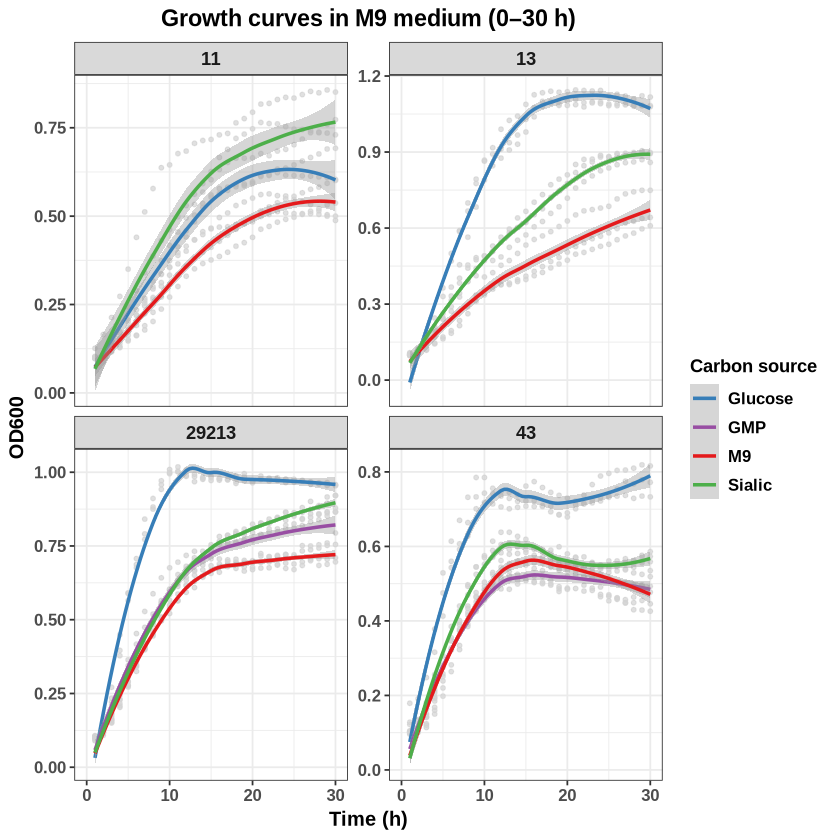

In [36]:
plotA_30h <- ggplot(
  long_od %>%
    filter(
      Strain != "None",
      Time_hr <= 30
    ),
  aes(x = Time_hr, y = OD600)
) +
  # Raw measurements in light gray
  geom_point(
    aes(group = Well),
    color = "lightgray",
    size = 1,
    alpha = 0.7
  ) +

  # Loess trend colored by carbon source
  geom_smooth(
    aes(color = Carbon, group = Carbon),
    method = "loess",
    span = 0.8,
    se = TRUE,
    linewidth = 1
  ) +

  facet_wrap(~Strain, scales = "free_y") +

  scale_color_manual(
    values = c(
      "M9"       = "#E41A1C",
      "Glucose"  = "#377EB8",
      "Sialic"   = "#4DAF4A",
      "GMP"      = "#984EA3"
    )
  ) +

  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon source",
    title = "Growth curves in M9 medium (0–30 h)"
  ) +

  coord_cartesian(xlim = c(0, 30)) +

  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5)
  )

plotA_30h

`geom_smooth()` using formula = 'y ~ x'


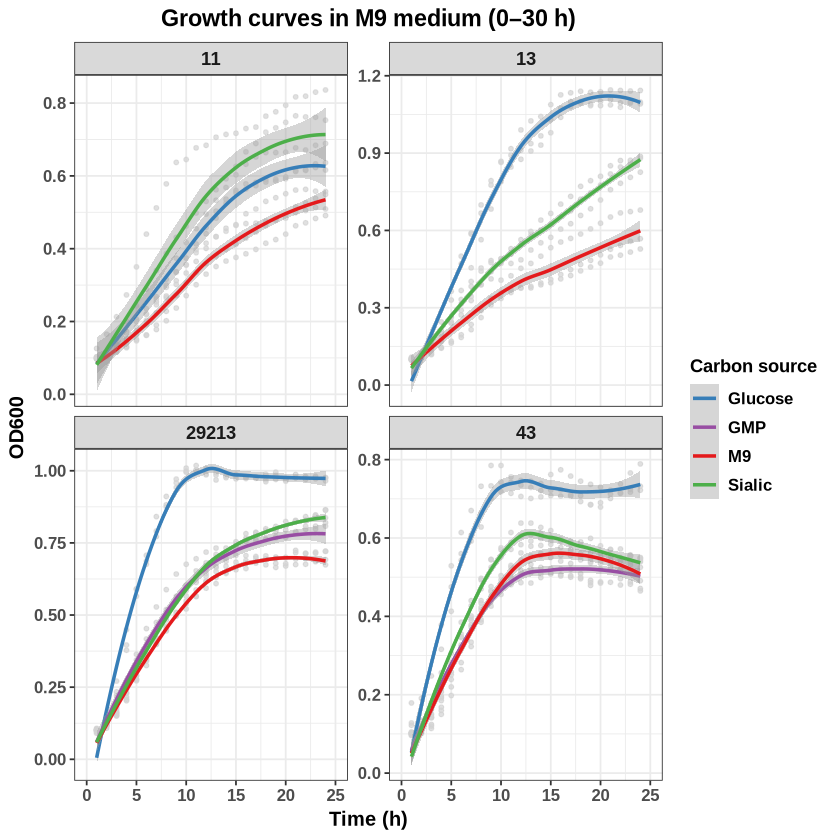

In [37]:
plotA_24h <- ggplot(
  long_od %>%
    filter(
      Strain != "None",
      Time_hr <= 24
    ),
  aes(x = Time_hr, y = OD600)
) +
  # Raw measurements in light gray
  geom_point(
    aes(group = Well),
    color = "lightgray",
    size = 1,
    alpha = 0.7
  ) +

  # Loess trend colored by carbon source
  geom_smooth(
    aes(color = Carbon, group = Carbon),
    method = "loess",
    span = 0.8,
    se = TRUE,
    linewidth = 1
  ) +

  facet_wrap(~Strain, scales = "free_y") +

  scale_color_manual(
    values = c(
      "M9"       = "#E41A1C",
      "Glucose"  = "#377EB8",
      "Sialic"   = "#4DAF4A",
      "GMP"      = "#984EA3"
    )
  ) +

  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon source",
    title = "Growth curves in M9 medium (0–30 h)"
  ) +

  coord_cartesian(xlim = c(0, 25)) +

  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5)
  )

plotA_24h

In [41]:
# Explore relative growth to assess carbohydrate catabolism (tp 24h)
# Step 1 — extract endpoint (24h)
od_24h <- long_od %>%
  filter(Time_hr == 20)
head(od_24h)

# 2. Step 2 — compute relative growth vs M9 (per strain + replicate)
od_rel <- od_24h %>%
  group_by(Strain) %>%
  mutate(
    m9_baseline = mean(OD600[Carbon == "M9"], na.rm = TRUE),
    rel_growth = OD600 / m9_baseline
  ) %>%
  ungroup()
head(od_rel)

# 3. Step 3 — summary stats
summary_od <- od_rel %>%
  group_by(Strain, Carbon) %>%
  summarise(
    mean_rel = mean(rel_growth, na.rm = TRUE),
    sd_rel   = sd(rel_growth, na.rm = TRUE),
    sem_rel  = sd(rel_growth) / sqrt(n()),
    n        = n(),
    .groups = "drop"
  )
head(summary_od)

Time_hr,Well,OD600,Strain,Carbon,Replicate
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
20,A1,0.077,None,M9,1
20,A2,0.081,None,Glucose,1
20,A3,0.081,None,Sialic,1
20,A4,0.084,None,GMP,1
20,B1,0.670,29213,M9,1
20,B2,0.969,29213,Glucose,1


Time_hr,Well,OD600,Strain,Carbon,Replicate,m9_baseline,rel_growth
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
20,A1,0.077,None,M9,1,0.0770000,1.0000000
20,A2,0.081,None,Glucose,1,0.0770000,1.0519481
20,A3,0.081,None,Sialic,1,0.0770000,1.0519481
20,A4,0.084,None,GMP,1,0.0770000,1.0909091
20,B1,0.670,29213,M9,1,0.6826667,0.9814453
20,B2,0.969,29213,Glucose,1,0.6826667,1.4194336


Strain,Carbon,mean_rel,sd_rel,sem_rel,n
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>
11,Glucose,1.230976,0.26653144,0.15388200,3
11,M9,1.000000,0.11213486,0.06474109,3
11,Sialic,1.381145,0.20663747,0.11930220,3
13,Glucose,2.069116,0.05157606,0.02977745,3
13,M9,1.000000,0.15286014,0.08825384,3
13,Sialic,1.434620,0.08689691,0.05016996,3


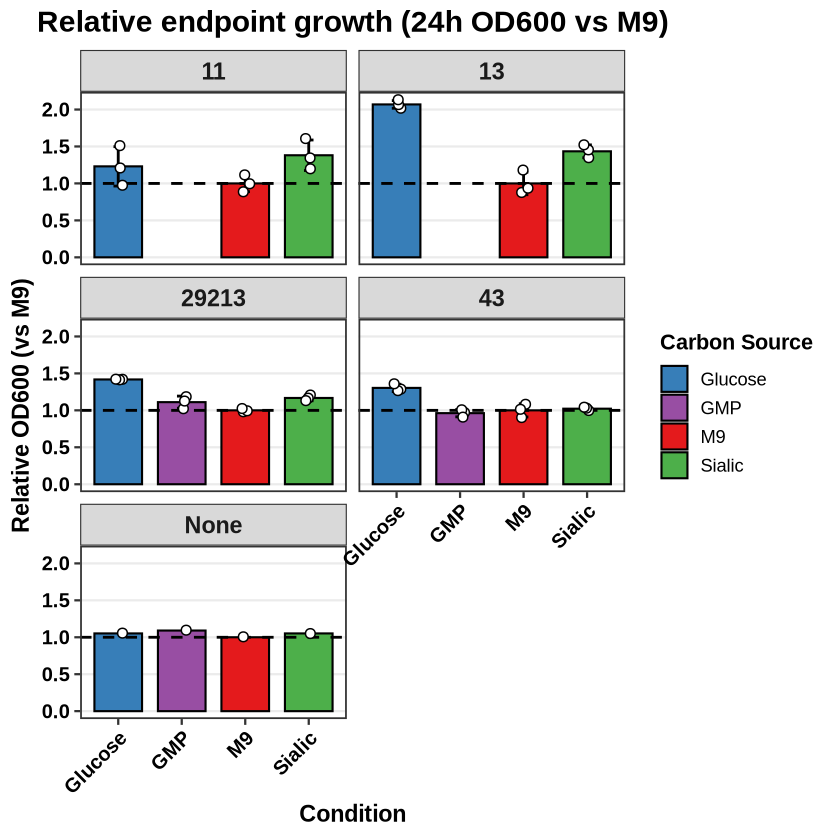

In [42]:
# Plot
library(ggplot2)

ggplot(summary_od, aes(x = Carbon, y = mean_rel, fill = Carbon)) +
  
  geom_col(
    color = "black",
    width = 0.75,
    linewidth = 0.6
  ) +
  
  geom_errorbar(
    aes(
      ymin = mean_rel - sd_rel,
      ymax = mean_rel + sd_rel
    ),
    width = 0.15,
    linewidth = 0.8
  ) +
  geom_hline(
  yintercept = 1,
  linetype = "dashed",
  linewidth = 0.8,
  color = "black"
) +
  geom_jitter(
    data = od_rel,
    aes(x = Carbon, y = rel_growth),
    width = 0.08,
    size = 2.3,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  
  facet_wrap(~Strain, ncol = 2) +
  
  scale_fill_manual(values = c(
      "M9"       = "#E41A1C",
      "Glucose"  = "#377EB8",
      "Sialic"   = "#4DAF4A",
      "GMP"      = "#984EA3"  )) +
  
  labs(
    title = "Relative endpoint growth (24h OD600 vs M9)",
    x = "Condition",
    y = "Relative OD600 (vs M9)",
    fill = "Carbon Source"
  ) +
  
  theme_bw(base_size = 14) +
  
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 14, face = "bold"),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12, face = "bold", colour = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.title = element_text(size = 13, face = "bold"),
    legend.text = element_text(size = 11),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(linewidth = 1)
  )

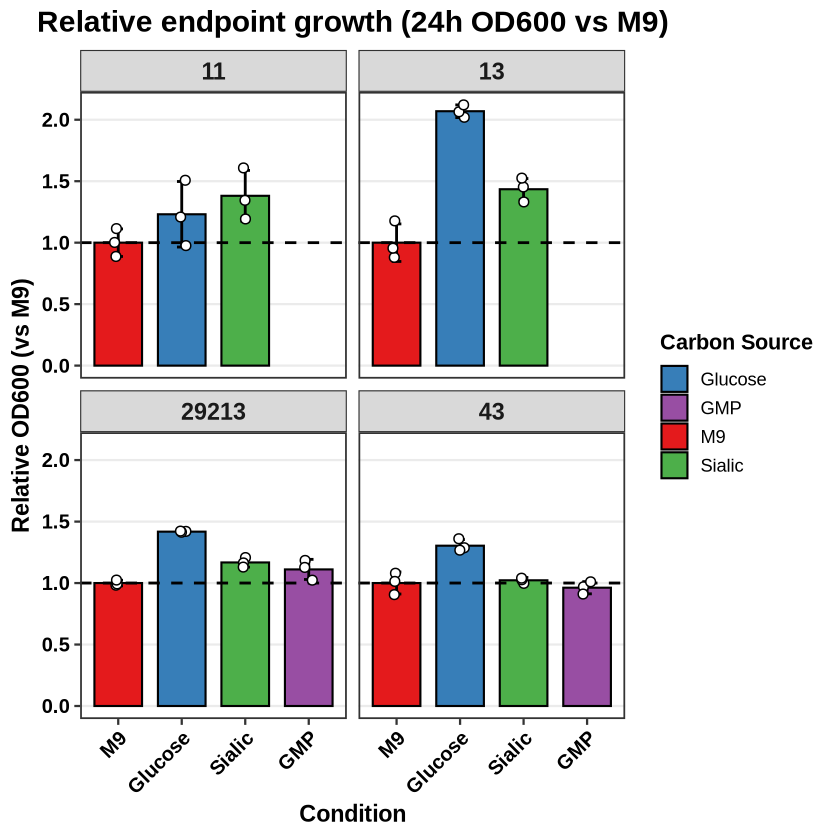

In [46]:
# Plot
library(ggplot2)
library(dplyr)

ggplot(
  summary_od %>%
    filter(Strain != "None"),
  aes(x = Carbon, y = mean_rel, fill = Carbon)
) +
  
  # Mean bars
  geom_col(
    color = "black",
    width = 0.75,
    linewidth = 0.6
  ) +
  
  # SD error bars
  geom_errorbar(
    aes(
      ymin = mean_rel - sd_rel,
      ymax = mean_rel + sd_rel
    ),
    width = 0.15,
    linewidth = 0.8
  ) +
  
  # Reference line (M9 = 1)
  geom_hline(
    yintercept = 1,
    linetype = "dashed",
    linewidth = 0.8,
    color = "black"
  ) +
  
  # Individual replicates
  geom_jitter(
    data = od_rel %>%
      filter(Strain != "None"),
    aes(x = Carbon, y = rel_growth),
    width = 0.08,
    size = 2.3,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  
  facet_wrap(~Strain, ncol = 2) +
  
  scale_fill_manual(
    values = c(
      "M9"       = "#E41A1C",
      "Glucose"  = "#377EB8",
      "Sialic"   = "#4DAF4A",
      "GMP"      = "#984EA3"
    )
  ) +
  
  scale_x_discrete(
    limits = c("M9", "Glucose", "Sialic", "GMP")
  ) +
  
  labs(
    title = "Relative endpoint growth (24h OD600 vs M9)",
    x = "Condition",
    y = "Relative OD600 (vs M9)",
    fill = "Carbon Source"
  ) +
  
  theme_bw(base_size = 14) +
  
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 14, face = "bold"),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12, face = "bold", colour = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.title = element_text(size = 13, face = "bold"),
    legend.text = element_text(size = 11),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(linewidth = 1)
  )